In [1]:
import json
import shutil
import random
from pathlib import Path

import numpy as np
import nibabel as nib
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from ipywidgets import interact

SRC_DIR = Path(r"D:\master_experiments\data\raw\archive\BraTS2020_TrainingData\MICCAI_BraTS2020_TrainingData")
OUT_DIR = Path(r"D:\master_experiments\data\splits\BraTS2020_Splits")

SEED = 42
SPLIT = (0.70, 0.15, 0.15)
N_BINS = 5

FAIL_IF_OUTDIR_NOT_EMPTY = True
REQUIRED_KEYS = ["flair", "t1", "t1ce", "t2", "seg"]

In [2]:
def find_nii(patient_dir: Path, key: str) -> Path:
    for cand in [patient_dir / f"{key}.nii", patient_dir / f"{key}.nii.gz"]:
        if cand.exists():
            return cand

    if key == "t1":
        cands = list(patient_dir.glob("*t1*.nii*"))
        cands = [c for c in cands if "t1ce" not in c.name.lower()]
    else:
        cands = list(patient_dir.glob(f"*{key}*.nii*"))

    if not cands:
        raise FileNotFoundError(f"Não achei '{key}' em {patient_dir}")

    cands = sorted(cands, key=lambda p: len(p.name))
    return cands[0]

def validate_patient_folder(pdir: Path):
    return {k: find_nii(pdir, k) for k in REQUIRED_KEYS}

patient_dirs = sorted([p for p in SRC_DIR.iterdir() if p.is_dir()])

folders_count_df = pd.DataFrame({"total_patient_folders": [len(patient_dirs)]})

preview_rows = []
for p in patient_dirs[:3]:
    files = validate_patient_folder(p)
    preview_rows.append({"patient_id": p.name, **{k: files[k].name for k in REQUIRED_KEYS}})

preview_df = pd.DataFrame(preview_rows)

display(folders_count_df)
display(preview_df)

,total_patient_folders
0,350


,patient_id,flair,t1,t1ce,t2,seg
0,BraTS20_Training_001,BraTS20_Training_001_flair.nii,BraTS20_Training_001_t1.nii,BraTS20_Training_001_t1ce.nii,BraTS20_Training_001_t2.nii,BraTS20_Training_001_seg.nii
1,BraTS20_Training_002,BraTS20_Training_002_flair.nii,BraTS20_Training_002_t1.nii,BraTS20_Training_002_t1ce.nii,BraTS20_Training_002_t2.nii,BraTS20_Training_002_seg.nii
2,BraTS20_Training_003,BraTS20_Training_003_flair.nii,BraTS20_Training_003_t1.nii,BraTS20_Training_003_t1ce.nii,BraTS20_Training_003_t2.nii,BraTS20_Training_003_seg.nii


In [3]:
def lesion_voxel_count(seg_path: Path) -> int:
    img = nib.load(str(seg_path))
    data = np.asanyarray(img.dataobj)
    return int(np.count_nonzero(data))

patients = []
errors = []

for pdir in patient_dirs:
    try:
        files = validate_patient_folder(pdir)
        vox = lesion_voxel_count(files["seg"])
        patients.append(
            {
                "id": pdir.name,
                "path": str(pdir),
                "lesion_voxels": vox,
                **{f"file_{k}": str(files[k]) for k in REQUIRED_KEYS},
            }
        )
    except Exception as e:
        errors.append({"id": pdir.name, "error": str(e)})

patients_df = pd.DataFrame(patients)
errors_df = pd.DataFrame(errors)

patients_summary_df = pd.DataFrame(
    [
        {"metric": "valid_patients", "value": len(patients)},
        {"metric": "errors", "value": len(errors)},
    ]
)

display(patients_summary_df)

,metric,value
0,valid_patients,350
1,errors,0


In [4]:
def allocate_counts(target_total: int, bin_sizes):
    total = sum(bin_sizes)
    if total == 0:
        return [0] * len(bin_sizes)

    quotas = [target_total * (b / total) for b in bin_sizes]
    floors = [int(np.floor(q)) for q in quotas]
    remainder = target_total - sum(floors)

    residues = [q - f for q, f in zip(quotas, floors)]
    order = np.argsort(residues)[::-1]

    out = floors[:]
    i = 0
    while remainder > 0 and i < len(order):
        out[int(order[i])] += 1
        remainder -= 1
        i += 1

    return out

def stratified_split_by_lesion(patients_df: pd.DataFrame, seed=42, n_bins=5, split=(0.7, 0.15, 0.15)):
    rng = random.Random(seed)

    ids = patients_df["id"].tolist()
    vols = patients_df["lesion_voxels"].to_numpy(dtype=np.float64)

    n_total = len(ids)
    n_train = int(round(n_total * split[0]))
    n_val = int(round(n_total * split[1]))
    n_test = n_total - n_train - n_val

    qs = np.linspace(0, 1, n_bins + 1)
    edges = np.quantile(vols, qs)
    internal_edges = np.unique(edges[1:-1])

    if internal_edges.size == 0:
        rng.shuffle(ids)
        return ids[:n_train], ids[n_train:n_train + n_val], ids[n_train + n_val:]

    bin_idx = np.digitize(vols, internal_edges, right=True)
    n_eff_bins = int(bin_idx.max() + 1)

    bins = [[] for _ in range(n_eff_bins)]
    for pid, b in zip(ids, bin_idx):
        bins[int(b)].append(pid)

    for b in bins:
        rng.shuffle(b)

    bin_sizes = [len(b) for b in bins]
    train_counts = allocate_counts(n_train, bin_sizes)

    remaining_sizes = [bs - tc for bs, tc in zip(bin_sizes, train_counts)]
    val_counts = allocate_counts(n_val, remaining_sizes)

    train_ids, val_ids, test_ids = [], [], []
    for b_i, b_list in enumerate(bins):
        t = train_counts[b_i]
        v = val_counts[b_i]
        train_ids.extend(b_list[:t])
        val_ids.extend(b_list[t:t + v])
        test_ids.extend(b_list[t + v:])

    if not (len(train_ids) == n_train and len(val_ids) == n_val and len(test_ids) == n_test):
        raise RuntimeError("Split sizes inconsistentes")

    return train_ids, val_ids, test_ids

train_ids, val_ids, test_ids = stratified_split_by_lesion(
    patients_df,
    seed=SEED,
    n_bins=N_BINS,
    split=SPLIT
)

splits = {"train": train_ids, "val": val_ids, "test": test_ids}

split_order = ["train", "val", "test"]
split_counts_df = (
    pd.DataFrame([{"split": k, "count": len(v)} for k, v in splits.items()])
      .assign(split=lambda df: pd.Categorical(df["split"], categories=split_order, ordered=True))
      .sort_values("split")
      .reset_index(drop=True)
)

patients_by_id = patients_df.set_index("id").to_dict(orient="index")

display(split_counts_df)

,split,count
0,train,245
1,val,52
2,test,53


In [5]:
def ensure_outdir_clean(out_dir: Path, fail_if_not_empty=True):
    out_dir.mkdir(parents=True, exist_ok=True)
    if fail_if_not_empty and any(out_dir.iterdir()):
        raise RuntimeError(f"OUT_DIR não está vazio: {out_dir}")

def copy_patient_folder(src: Path, dst: Path):
    dst.parent.mkdir(parents=True, exist_ok=True)
    shutil.copytree(src, dst, dirs_exist_ok=True)

ensure_outdir_clean(OUT_DIR, fail_if_not_empty=FAIL_IF_OUTDIR_NOT_EMPTY)

for split_name, ids in splits.items():
    for pid in ids:
        src = Path(patients_by_id[pid]["path"])
        dst = OUT_DIR / split_name / pid
        copy_patient_folder(src, dst)

metadata = {
    "src_dir": str(SRC_DIR),
    "out_dir": str(OUT_DIR),
    "seed": SEED,
    "split": {"train": SPLIT[0], "val": SPLIT[1], "test": SPLIT[2]},
    "counts": {k: len(v) for k, v in splits.items()},
    "ids": splits,
    "note": "Split por paciente (1 pasta = 1 paciente). Estratificado por volume de lesão (voxels != 0 em seg)."
}

metadata_path = OUT_DIR / "splits_metadata.json"
with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

metadata_path

WindowsPath('D:/master_experiments/data/splits/BraTS2020_Splits/splits_metadata.json')

,split,n,min,median,mean,max
0,train,245,7285,90740,99644.942857,361783
1,val,52,12470,91609,101831.980769,298075
2,test,53,15762,80396,95115.849057,231951


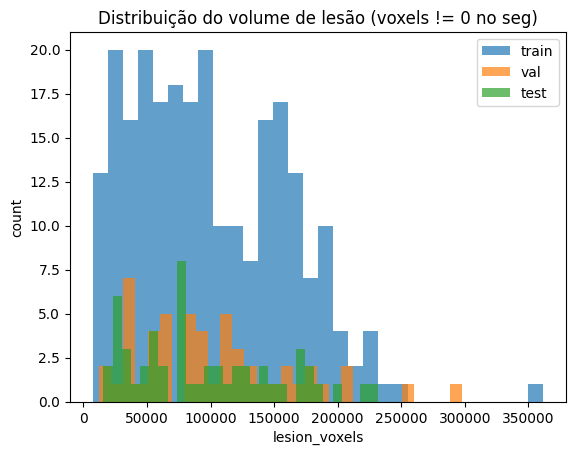

In [6]:
def lesion_array(ids_list):
    return patients_df.set_index("id").loc[ids_list, "lesion_voxels"].to_numpy(dtype=np.float64)

train_v = lesion_array(train_ids)
val_v = lesion_array(val_ids)
test_v = lesion_array(test_ids)

voxel_stats_df = pd.DataFrame(
    [
        {"split": "train", "n": len(train_v), "min": int(train_v.min()), "median": int(np.median(train_v)), 
         "mean": float(train_v.mean()), "max": int(train_v.max())},
        {"split": "val",   "n": len(val_v),   "min": int(val_v.min()),   "median": int(np.median(val_v)),   
         "mean": float(val_v.mean()),   "max": int(val_v.max())},
        {"split": "test",  "n": len(test_v),  "min": int(test_v.min()),  "median": int(np.median(test_v)),  
         "mean": float(test_v.mean()),  "max": int(test_v.max())},
    ]
)

voxel_stats_df = (
    voxel_stats_df
    .assign(split=lambda df: pd.Categorical(df["split"], categories=split_order, ordered=True))
    .sort_values("split")
    .reset_index(drop=True)
)

display(voxel_stats_df)

plt.figure()
plt.hist(train_v, bins=30, alpha=0.7, label="train")
plt.hist(val_v, bins=30, alpha=0.7, label="val")
plt.hist(test_v, bins=30, alpha=0.7, label="test")
plt.title("Distribuição do volume de lesão (voxels != 0 no seg)")
plt.xlabel("lesion_voxels")
plt.ylabel("count")
plt.legend()
plt.show()

,split,modality,shape,count
0,train,flair,"(240, 240, 155)",245
1,train,seg,"(240, 240, 155)",245
2,train,t1,"(240, 240, 155)",245
3,train,t1ce,"(240, 240, 155)",245
4,train,t2,"(240, 240, 155)",245
5,val,flair,"(240, 240, 155)",52
6,val,seg,"(240, 240, 155)",52
7,val,t1,"(240, 240, 155)",52
8,val,t1ce,"(240, 240, 155)",52
9,val,t2,"(240, 240, 155)",52


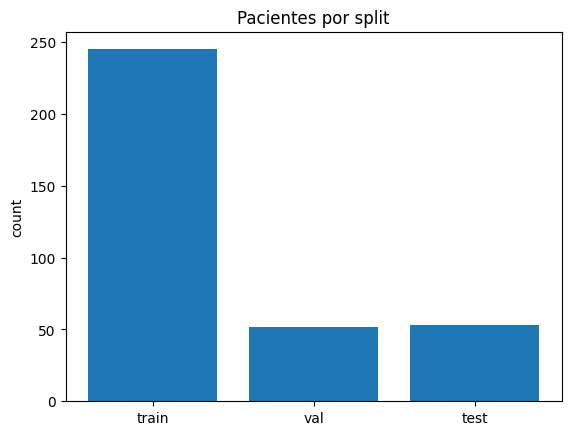

In [7]:
def load_shape(nifti_path: Path):
    img = nib.load(str(nifti_path))
    return tuple(img.shape)

def collect_shapes_for_split(split_name: str):
    base = OUT_DIR / split_name
    pdirs = sorted([p for p in base.iterdir() if p.is_dir()])

    rows = []
    for pdir in pdirs:
        files = {k: find_nii(pdir, k) for k in REQUIRED_KEYS}
        for k in REQUIRED_KEYS:
            rows.append(
                {
                    "split": split_name,
                    "patient_id": pdir.name,
                    "modality": k,
                    "shape": str(load_shape(files[k])),
                }
            )
    return rows

shape_rows = []
for sname in split_order:
    shape_rows.extend(collect_shapes_for_split(sname))

shapes_df = pd.DataFrame(shape_rows)

shape_counts_df = (
    shapes_df.groupby(["split", "modality", "shape"], as_index=False, observed=False)
    .size()
    .rename(columns={"size": "count"})
)

shape_counts_df = (
    shape_counts_df
    .assign(split=lambda df: pd.Categorical(df["split"], categories=split_order, ordered=True))
    .sort_values(["split", "modality", "count"], ascending=[True, True, False])
    .reset_index(drop=True)
)

top_shapes_df = (
    shape_counts_df.groupby(["split", "modality"], as_index=False, observed=False)
    .head(3)
    .reset_index(drop=True)
)

display(top_shapes_df)

plt.figure()
plt.bar(split_order, [len(train_ids), len(val_ids), len(test_ids)])
plt.title("Pacientes por split")
plt.ylabel("count")
plt.show()

Paciente: BraTS20_Training_061 | shape: (240, 240, 155) | mask: WT


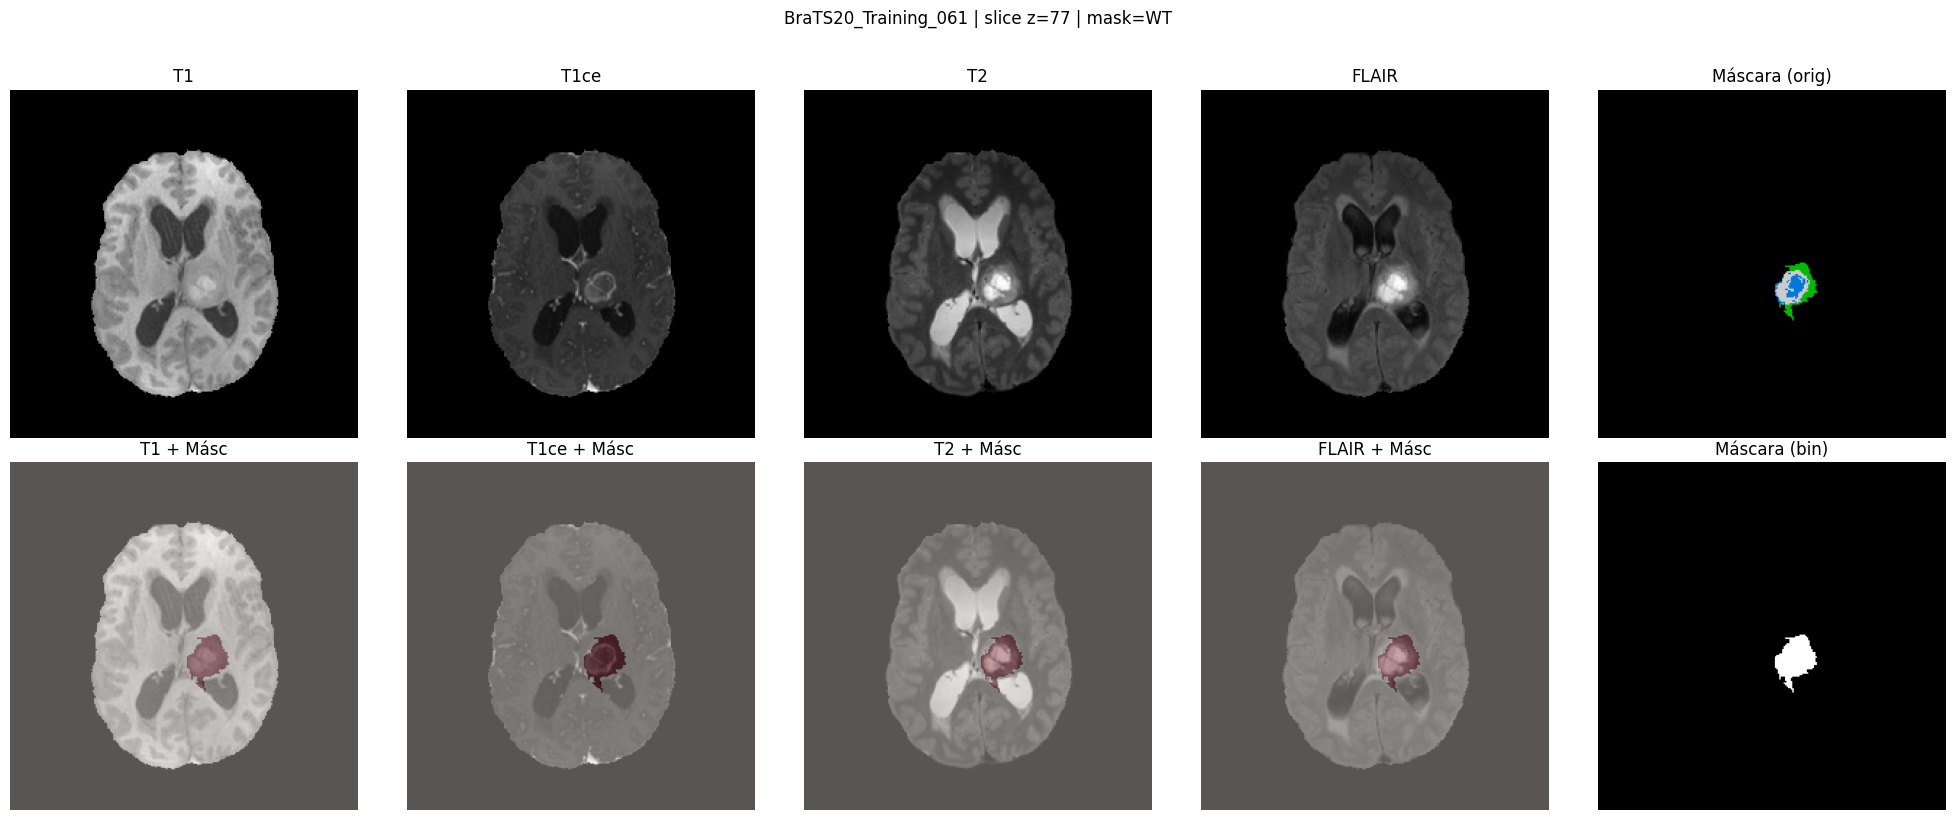

In [8]:
# ---------- helpers ----------
def patient_dir_from_out(out_dir: Path, patient_id: str) -> Path:
    matches = list(out_dir.glob(f"*/{patient_id}"))
    if not matches:
        raise FileNotFoundError(f"Paciente '{patient_id}' não encontrado em {out_dir}/(train|val|test)/{patient_id}")
    return matches[0]

def load_nii_canonical(path: Path):
    img = nib.as_closest_canonical(nib.load(str(path)))
    data = np.asanyarray(img.dataobj)
    return data 

def brats_mask(seg: np.ndarray, which="WT"):
    which = which.upper()
    if which == "WT":
        return (seg > 0).astype(np.uint8)
    if which == "TC":
        return np.isin(seg, [1, 4]).astype(np.uint8)
    if which == "ET":
        return (seg == 4).astype(np.uint8)
    raise ValueError("which deve ser 'WT', 'TC' ou 'ET'")

PATIENT_ID = train_ids[0]
MASK_KIND = "WT"          

pdir = patient_dir_from_out(OUT_DIR, PATIENT_ID)

t1_path    = find_nii(pdir, "t1")
t1ce_path  = find_nii(pdir, "t1ce")
t2_path    = find_nii(pdir, "t2")
flair_path = find_nii(pdir, "flair")
seg_path   = find_nii(pdir, "seg")

t1_20    = load_nii_canonical(t1_path)
t1c_20   = load_nii_canonical(t1ce_path)
t2_20    = load_nii_canonical(t2_path)
flair_20 = load_nii_canonical(flair_path)
seg_20   = load_nii_canonical(seg_path)

mask_bin_20 = brats_mask(seg_20, which=MASK_KIND)

Z20 = t1_20.shape[2]
print(f"Paciente: {PATIENT_ID} | shape: {t1_20.shape} | mask: {MASK_KIND}")

def viewer_20_fixed():
    z = Z20 // 2

    plt.figure(figsize=(20, 8))

    # ---------- LINHA DE CIMA ----------
    plt.subplot(2, 5, 1)
    plt.imshow(t1_20[:, :, z].T, cmap="gray", origin="lower")
    plt.title("T1")
    plt.axis("off")

    plt.subplot(2, 5, 2)
    plt.imshow(t1c_20[:, :, z].T, cmap="gray", origin="lower")
    plt.title("T1ce")
    plt.axis("off")

    plt.subplot(2, 5, 3)
    plt.imshow(t2_20[:, :, z].T, cmap="gray", origin="lower")
    plt.title("T2")
    plt.axis("off")

    plt.subplot(2, 5, 4)
    plt.imshow(flair_20[:, :, z].T, cmap="gray", origin="lower")
    plt.title("FLAIR")
    plt.axis("off")

    plt.subplot(2, 5, 5)
    plt.imshow(seg_20[:, :, z].T, cmap="nipy_spectral", origin="lower")
    plt.title("Máscara (orig)")
    plt.axis("off")

    # ---------- LINHA DE BAIXO ----------
    m = (mask_bin_20[:, :, z].T > 0).astype(np.uint8)

    plt.subplot(2, 5, 6)
    plt.imshow(t1_20[:, :, z].T, cmap="gray", origin="lower")
    plt.imshow(m, cmap="Reds", alpha=0.35, origin="lower")
    plt.title("T1 + Másc")
    plt.axis("off")

    plt.subplot(2, 5, 7)
    plt.imshow(t1c_20[:, :, z].T, cmap="gray", origin="lower")
    plt.imshow(m, cmap="Reds", alpha=0.35, origin="lower")
    plt.title("T1ce + Másc")
    plt.axis("off")

    plt.subplot(2, 5, 8)
    plt.imshow(t2_20[:, :, z].T, cmap="gray", origin="lower")
    plt.imshow(m, cmap="Reds", alpha=0.35, origin="lower")
    plt.title("T2 + Másc")
    plt.axis("off")

    plt.subplot(2, 5, 9)
    plt.imshow(flair_20[:, :, z].T, cmap="gray", origin="lower")
    plt.imshow(m, cmap="Reds", alpha=0.35, origin="lower")
    plt.title("FLAIR + Másc")
    plt.axis("off")

    plt.subplot(2, 5, 10)
    plt.imshow(m, cmap="gray", origin="lower")
    plt.title("Máscara (bin)")
    plt.axis("off")

    plt.suptitle(f"{PATIENT_ID} | slice z={z} | mask={MASK_KIND}", y=1.02)
    plt.tight_layout()
    plt.show()

viewer_20_fixed()